NAIMA SHARIFF

HW:0 PROBLEM 1 AND 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#Plot styling
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['lines.linewidth'] = 3


In [2]:
#Global parameters
xmin = 0
xmax = 2 * np.pi
nx = 100
dx = (xmax - xmin) / (nx - 1)
x = np.linspace(xmin, xmax, nx)

#Dense, log-spaced sequence of grid sizes for a smooth convergence curve
nx_values = np.unique(np.round(np.geomspace(25, 800, 13)).astype(int))


In [3]:
#Define function, its derivative, and the finite-difference operator
def fun(x):
    y = np.exp(np.sin(x))
    return y

def f_prime(x):
    return np.exp(np.sin(x)) * np.cos(x)

def f_double_prime(x):
    return np.exp(np.sin(x)) * (np.cos(x)**2 - np.sin(x))

def central_difference(f_values, h):
    df = np.zeros_like(f_values)
    df[1:-1] = (f_values[2:] - f_values[:-2]) / (2 * h)
    df[0] = (f_values[1] - f_values[0]) / h
    df[-1] = (f_values[-1] - f_values[-2]) / h
    return df

def second_difference(f_values, h):
    #Periodic boundaries: f_values[0] and f_values[-1] are the same physical
    #point (x=0 and x=2*pi), so the true neighbors wrap through f_values[-2]/f_values[1]
    d2f = np.zeros_like(f_values)
    d2f[1:-1] = (f_values[2:] - 2 * f_values[1:-1] + f_values[:-2]) / h**2
    d2f[0] = (f_values[1] - 2 * f_values[0] + f_values[-2]) / h**2
    d2f[-1] = (f_values[1] - 2 * f_values[-1] + f_values[-2]) / h**2
    return d2f


In [4]:
#Numerical and analytical solution on the base grid
f = fun(x)
df_dx = central_difference(f, dx)
df_dx_analytical = f_prime(x)


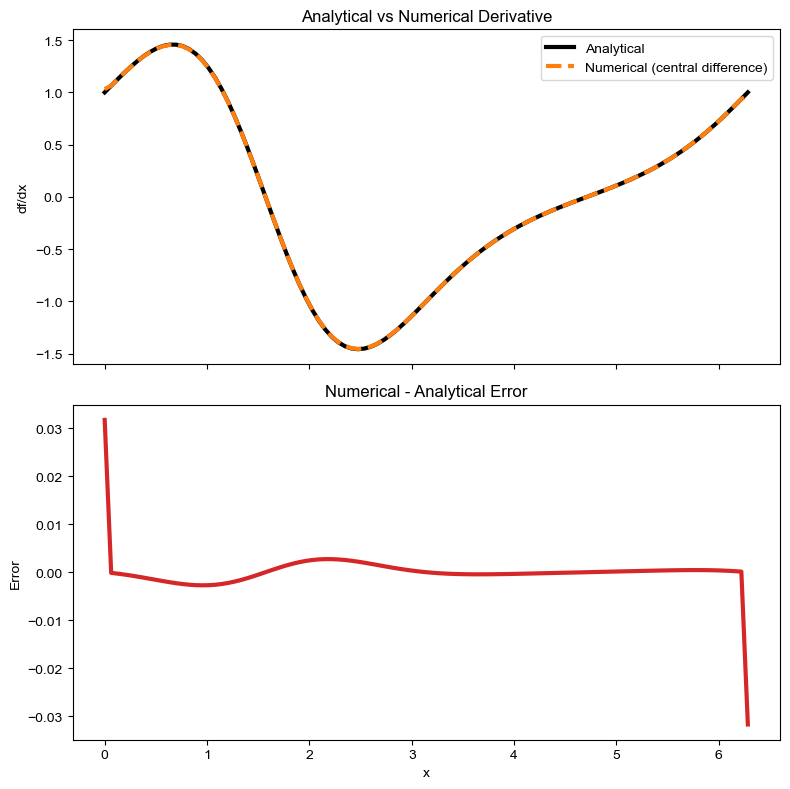

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axes[0].plot(x, df_dx_analytical, label="Analytical", color="black", linewidth=3)
axes[0].plot(x, df_dx, label="Numerical (central difference)", color="tab:orange", linestyle="--")
axes[0].set_ylabel("df/dx")
axes[0].set_title("Analytical vs Numerical Derivative")
axes[0].legend()

axes[1].plot(x, df_dx - df_dx_analytical, color="tab:red")
axes[1].set_xlabel("x")
axes[1].set_ylabel("Error")
axes[1].set_title("Numerical - Analytical Error")

plt.tight_layout()
plt.savefig("figures/hw0_first_derivative_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


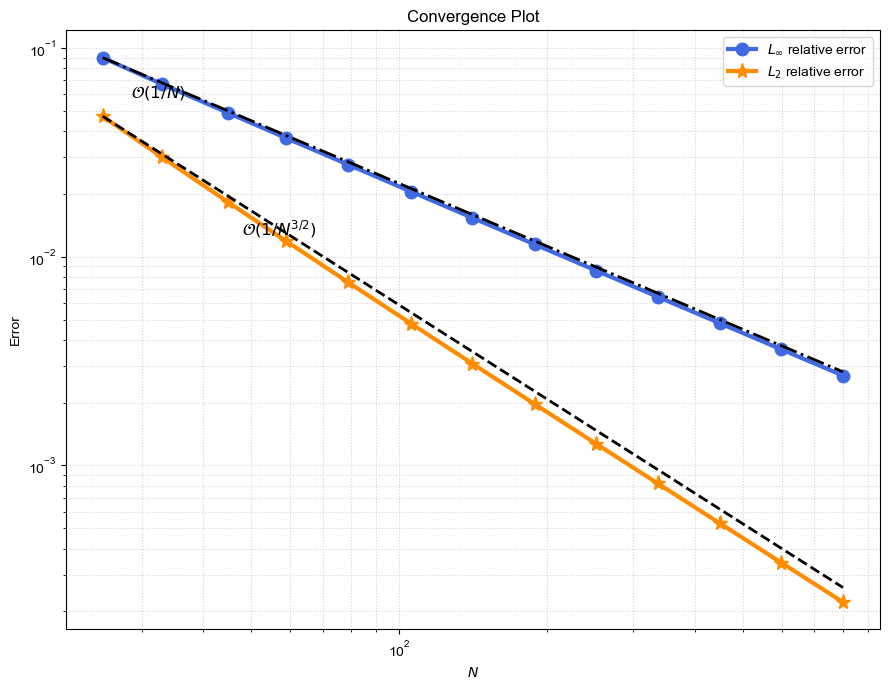

In [6]:
#Convergence study: relative error vs grid size N
error_inf = []
error_l2 = []

for n in nx_values:
    h = (xmax - xmin) / (n - 1)
    x_test = np.linspace(xmin, xmax, n)

    numerical_derivative = central_difference(fun(x_test), h)
    exact_derivative = f_prime(x_test)
    error = numerical_derivative - exact_derivative

    error_inf.append(
        np.linalg.norm(error, ord=np.inf) / np.linalg.norm(exact_derivative, ord=np.inf)
    )
    error_l2.append(
        np.linalg.norm(error, ord=2) / np.linalg.norm(exact_derivative, ord=2)
    )

error_inf = np.array(error_inf)
error_l2 = np.array(error_l2)
ref_inf = error_inf[0] * (nx_values[0] / nx_values)
ref_l2 = error_l2[0] * (nx_values[0] / nx_values) ** 1.5

fig, ax = plt.subplots(figsize=(9, 7))

ax.loglog(nx_values, error_inf, "o-", color="royalblue", markersize=9, label=r"$L_\infty$ relative error")
ax.loglog(nx_values, error_l2, "*-", color="darkorange", markersize=11, label=r"$L_2$ relative error")

ax.loglog(nx_values, ref_inf, "-.", color="black", linewidth=2)
ax.loglog(nx_values, ref_l2, "--", color="black", linewidth=2)

anchor = 2
ax.annotate(
    r"$\mathcal{O}(1/N)$",
    xy=(nx_values[anchor], ref_inf[anchor]),
    xytext=(-70, 10),
    textcoords="offset points",
    fontsize=12,
)
ax.annotate(
    r"$\mathcal{O}(1/N^{3/2})$",
    xy=(nx_values[anchor], ref_l2[anchor]),
    xytext=(10, -28),
    textcoords="offset points",
    fontsize=12,
)

ax.set_xlabel(r"$N$")
ax.set_ylabel("Error")
ax.set_title("Convergence Plot")
ax.grid(True, which="both", linestyle=":", color="lightgray")
ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.savefig("figures/hw0_first_derivative_convergence.png", dpi=150, bbox_inches="tight")
plt.show()


In [7]:
#Numerical and analytical second derivative on the base grid
d2f_dx2 = second_difference(f, dx)
d2f_dx2_analytical = f_double_prime(x)


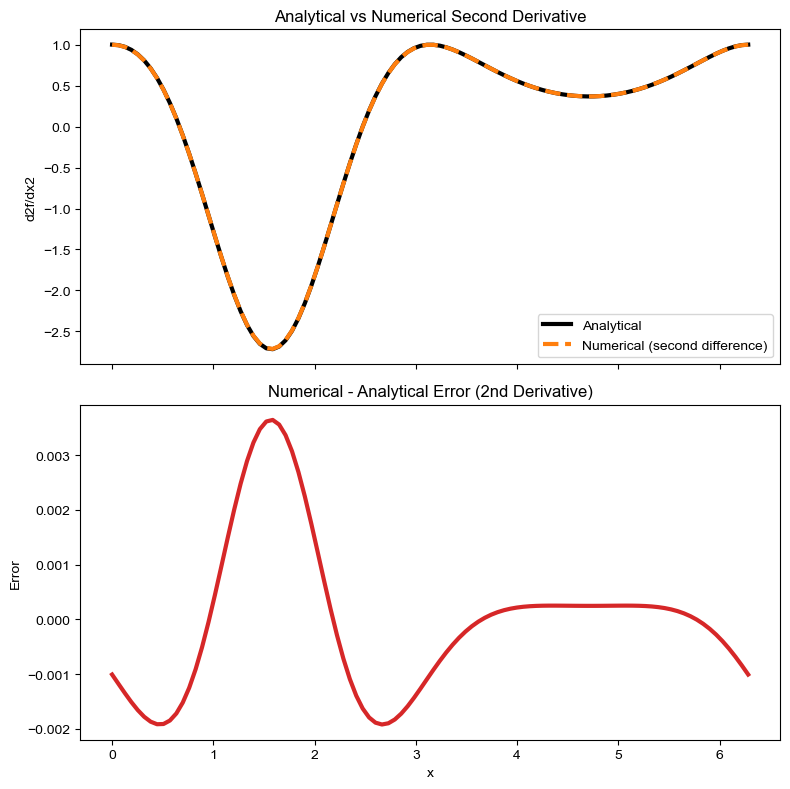

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axes[0].plot(x, d2f_dx2_analytical, label="Analytical", color="black")
axes[0].plot(x, d2f_dx2, label="Numerical (second difference)", color="tab:orange", linestyle="--")
axes[0].set_ylabel("d2f/dx2")
axes[0].set_title("Analytical vs Numerical Second Derivative")
axes[0].legend()

axes[1].plot(x, d2f_dx2 - d2f_dx2_analytical, color="tab:red")
axes[1].set_xlabel("x")
axes[1].set_ylabel("Error")
axes[1].set_title("Numerical - Analytical Error (2nd Derivative)")

plt.tight_layout()
plt.savefig("figures/hw0_second_derivative_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


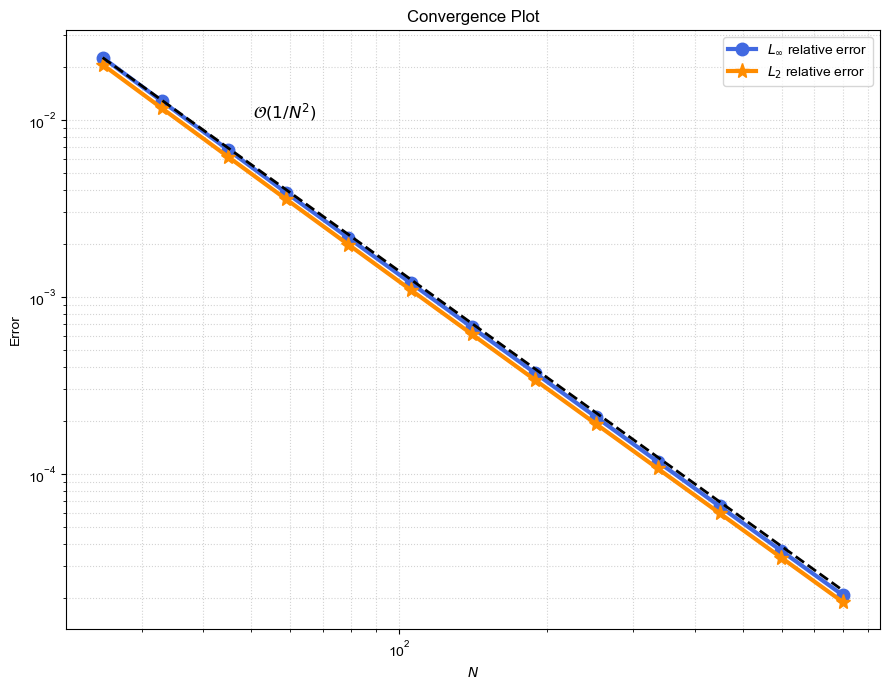

In [9]:
#Convergence study: relative error vs grid size N (second derivative)
error_inf_2 = []
error_l2_2 = []

for n in nx_values:
    h = (xmax - xmin) / (n - 1)
    x_test = np.linspace(xmin, xmax, n)

    numerical_second_derivative = second_difference(fun(x_test), h)
    exact_second_derivative = f_double_prime(x_test)
    error = numerical_second_derivative - exact_second_derivative

    error_inf_2.append(
        np.linalg.norm(error, ord=np.inf) / np.linalg.norm(exact_second_derivative, ord=np.inf)
    )
    error_l2_2.append(
        np.linalg.norm(error, ord=2) / np.linalg.norm(exact_second_derivative, ord=2)
    )

error_inf_2 = np.array(error_inf_2)
error_l2_2 = np.array(error_l2_2)
reference = error_inf_2[0] * (nx_values[0] / nx_values) ** 2

fig, ax = plt.subplots(figsize=(9, 7))

ax.loglog(nx_values, error_inf_2, "o-", color="royalblue", markersize=9, label=r"$L_\infty$ relative error")
ax.loglog(nx_values, error_l2_2, "*-", color="darkorange", markersize=11, label=r"$L_2$ relative error")
ax.loglog(nx_values, reference, "--", color="black", linewidth=2)

anchor = 2
ax.annotate(
    r"$\mathcal{O}(1/N^2)$",
    xy=(nx_values[anchor], reference[anchor]),
    xytext=(18, 22),
    textcoords="offset points",
    fontsize=12,
)

ax.set_xlabel(r"$N$")
ax.set_ylabel("Error")
ax.set_title("Convergence Plot")
ax.grid(True, which="both", linestyle=":", color="lightgray")
ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.savefig("figures/hw0_second_derivative_convergence.png", dpi=150, bbox_inches="tight")
plt.show()
